# Credible Answers to Hard Questions: Differences-in-Differences for Natural Experiments (coding exercises - R)


## Tabla de contenidos

- [Chapter 1](#c-1)

- [Chapter 2](#c-2)

- [Chapter 3](#c-3)

- [Chapter 4](#c-4)

- [Chapter 5](#c-5)

- [Chapter 6](#c-6)

- [Chapter 7](#c-7)

- [Chapter 8](#c-8)

## Chapter 1 — Downloading and Preparing Data

This chapter covers the basic setup required to work with **all the databases in the DID Textbook**.

By the end of this chapter, the student will be able to:
- define their working folder,
- download the book's datasets,
- open any database included in the repository.

### 1.1 Working Folder

Before starting, R
 needs to know which folder to work in.

**Instruction**
Replace the path in the following command with an existing folder on your computer.

In [1]:
# Clean up the environment
rm(list = ls())

options(max.print = 1e6)

# Change the working directory
setwd("/Users/karlavega/Documents/GitHub/did_book")

### 1.2 Downloading the Data

The replication data and files are not downloaded from Stata.
Instead, all datasets are already stored locally in the project folder cloned from GitHub.
The folder structure is:

In [2]:
data_path <- "cc_xd_didtextbook_2025_9_30"


### 1.3 Loading Databases
From this point onward, the datasets used throughout the book are loaded directly from local files.
In R, the equivalent of Stata’s use command is read_dta() for Stata .dta files.
Each chapter specifies which dataset should be loaded.

In [3]:
# Load required library
library(haven)
library(dplyr)
library(stringr)
library(purrr)
library(fixest)
library(broom)
library(ggplot2)
library(car)
library(didimputation)
library(pretrends)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:purrr’:

    some


The following object is masked from ‘package:dplyr’:

    recode


Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:purrr’:

    transpose


The following objects are masked from ‘package:dplyr’:

    between, first, last




## Chapter 3 — Basic Difference in Differences

This chapter introduces the fundamental Difference-in-Differences (DiD) estimators:

- static TWFE regression,
- equivalence between TWFE and canonical DiD,
- event study and pre-trend test,
- extensions for evaluating assumptions and heterogeneity.

This chapter uses data from **Moser and Voena (2012)** to illustrate the basic Difference-in-Differences estimators.

Before starting the estimations, we load the corresponding dataset.

In [4]:
setwd("/Users/karlavega/Documents/GitHub/did_book")

df <- read_dta(
  "/Users/karlavega/Documents/GitHub/did_book/cc_xd_didtextbook_2025_9_30/Data sets/Moser and Voena 2012/moser_voena_didtextbook.dta"
)

# Secure “safe” rates
df <- df %>%
  mutate(
    year = as.integer(year),
    subclass = as.factor(subclass),
    treatmentgroup = as.integer(treatmentgroup),
    post = as.integer(post)
  )

# Helpers: list of lead/lag variables as in Stata: reltimeminus*, reltimeplus*
leads <- names(df)[str_detect(names(df), "^reltimeminus\\d+$")]
lags  <- names(df)[str_detect(names(df), "^reltimeplus\\d+$")]

### 3.1 Static TWFE Regression

We estimate a model with fixed unit (`subclass`) and time (`year`) effects.
Standard errors are grouped at the `subclass` level.

In [11]:
m_twfe_1 <- feols(
  patents ~ twea | subclass + year,
  data = df,
  cluster = ~subclass
)

summary(m_twfe_1)


OLS estimation, Dep. Var.: patents
Observations: 289,920
Fixed-effects: subclass: 7,248,  year: 40
Standard-errors: Clustered (subclass) 
     Estimate Std. Error t value  Pr(>|t|)    
twea 0.288262   0.038887 7.41278 1.377e-13 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 0.977862     Adj. R2: 0.465316
                 Within R2: 9.571e-4

### 3.2 Equivalence between TWFE and canonical DiD

In this case, the coefficient of `twea` coincides with the classical DiD estimator.

In [12]:
# reg patents treatmentgroup post twea, cluster(subclass)
m_did <- feols(patents ~ treatmentgroup + post + twea, data = df, cluster = ~subclass)
summary(m_did)

OLS estimation, Dep. Var.: patents
Observations: 289,920
Standard-errors: Clustered (subclass) 
                Estimate Std. Error  t value   Pr(>|t|)    
(Intercept)     0.314366   0.009819 32.01738  < 2.2e-16 ***
treatmentgroup -0.178087   0.033815 -5.26648 1.4306e-07 ***
post            0.299667   0.009061 33.07069  < 2.2e-16 ***
twea            0.288262   0.038885  7.41326 1.3721e-13 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 1.34503   Adj. R2: 0.013827

### 3.3 Treatment Randomization Test

This test assesses whether the treatment and control groups differ before treatment.

In [15]:
# reg patents treatmentgroup if year<=1918, cluster(subclass)
mm_rand <- feols(patents ~ treatmentgroup, data = df %>% filter(year <= 1918), cluster = ~subclass)
summary(mm_rand)

OLS estimation, Dep. Var.: patents
Observations: 137,712
Standard-errors: Clustered (subclass) 
                Estimate Std. Error  t value   Pr(>|t|)    
(Intercept)     0.314366   0.009819 32.01743  < 2.2e-16 ***
treatmentgroup -0.178087   0.033815 -5.26649 1.4306e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 1.08737   Adj. R2: 0.001177

### 3.4 Event-study TWFE

Dynamic effects are estimated using leads and lags. The key test is that the pre-treatment coefficients are jointly zero.

In [16]:
f_es_full <- as.formula(
  paste0(
    "patents ~ i(year) + treatmentgroup + ",
    paste(c(leads, lags), collapse = " + ")
  )
)

m_es_full <- feols(f_es_full, data = df, cluster = ~subclass)
summary(m_es_full)


OLS estimation, Dep. Var.: patents
Observations: 289,920
Standard-errors: Clustered (subclass) 
                Estimate Std. Error   t value   Pr(>|t|)    
(Intercept)     0.221788   0.009448 23.474449  < 2.2e-16 ***
year::1901      0.005787   0.008077  0.716454 4.7373e-01    
year::1902      0.006510   0.008753  0.743806 4.5702e-01    
year::1903      0.033999   0.009139  3.720027 2.0071e-04 ***
year::1904      0.018084   0.009042  1.999976 4.5540e-02 *  
year::1905      0.020255   0.009455  2.142237 3.2208e-02 *  
year::1906      0.043258   0.009662  4.477224 7.6778e-06 ***
year::1907      0.106626   0.010872  9.807737  < 2.2e-16 ***
year::1908      0.057726   0.010354  5.575068 2.5633e-08 ***
year::1909      0.088108   0.011342  7.768296 9.0506e-15 ***
year::1910      0.058304   0.010213  5.708680 1.1835e-08 ***
year::1911      0.087095   0.011429  7.620784 2.8420e-14 ***
year::1912      0.110243   0.011363  9.702067  < 2.2e-16 ***
year::1913      0.066985   0.011756  5.697972 1.25

[1] NA

[1] 0.02352017

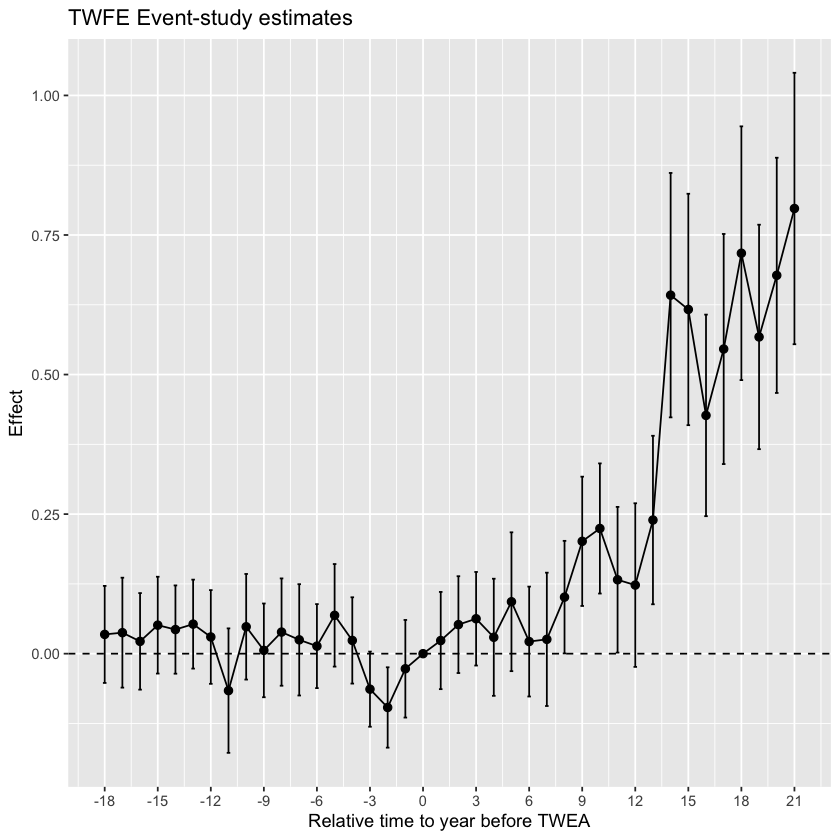

In [17]:
# Joint test de pre-trends
pre_terms <- leads  
wald_pre <- wald(m_es_full, paste(pre_terms, collapse = " = 0, "), cluster = "subclass")
wald_pre

# ---- Event-study plot 
tidy_es <- broom::tidy(m_es_full, conf.int = TRUE) %>%
  filter(term %in% c(leads, lags)) %>%
  mutate(
    rel_time = case_when(
      str_detect(term, "^reltimeminus") ~ -as.integer(str_extract(term, "\\d+")),
      str_detect(term, "^reltimeplus")  ~  as.integer(str_extract(term, "\\d+"))
    )
  ) %>%
  arrange(rel_time)


# Add period 0 with effect 0

tidy_es0 <- bind_rows(
  tibble(term = "t0", estimate = 0, conf.low = 0, conf.high = 0, rel_time = 0),
  tidy_es
) %>% arrange(rel_time)

p1 <- ggplot(tidy_es0, aes(x = rel_time, y = estimate)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_line() +
  geom_point(size = 2) +
  geom_errorbar(aes(ymin = conf.low, ymax = conf.high), width = 0.2) +
  labs(
    title = "TWFE Event-study estimates",
    x = "Relative time to year before TWEA",
    y = "Effect"
  ) +
  scale_x_continuous(breaks = seq(-18, 21, by = 3))
p1

ggsave(
  filename = "/Users/karlavega/Documents/GitHub/did_book/R/graphES_moser1.pdf",
  plot = p1, width = 8, height = 5
)

# ---- Manual verification of DID 1919 vs 1918  ----
m1 <- df %>% filter(year == 1919, treatmentgroup == 1) %>% summarise(m = mean(patents, na.rm = TRUE)) %>% pull(m)
m2 <- df %>% filter(year == 1918, treatmentgroup == 1) %>% summarise(m = mean(patents, na.rm = TRUE)) %>% pull(m)
m3 <- df %>% filter(year == 1919, treatmentgroup == 0) %>% summarise(m = mean(patents, na.rm = TRUE)) %>% pull(m)
m4 <- df %>% filter(year == 1918, treatmentgroup == 0) %>% summarise(m = mean(patents, na.rm = TRUE)) %>% pull(m)
did_by_hand <- (m1 - m2) - (m3 - m4)
did_by_hand


### 3.5 Event-study without pre-treatment periods

The model is re-estimated excluding the leads, allowing for comparison with the dynamic DiD in the post-treatment period.


OLS estimation, Dep. Var.: patents
Observations: 289,920
Standard-errors: Clustered (subclass) 
                Estimate Std. Error   t value   Pr(>|t|)    
(Intercept)     0.314366   0.009819 32.015171  < 2.2e-16 ***
yearpost::1919  0.091016   0.010257  8.873601  < 2.2e-16 ***
yearpost::1920  0.083349   0.011205  7.438752 1.1333e-13 ***
yearpost::1921  0.129356   0.012057 10.728906  < 2.2e-16 ***
yearpost::1922  0.144691   0.011838 12.222170  < 2.2e-16 ***
yearpost::1923  0.101867   0.012348  8.249385  < 2.2e-16 ***
yearpost::1924  0.152359   0.013354 11.409478  < 2.2e-16 ***
yearpost::1925  0.166248   0.013641 12.187462  < 2.2e-16 ***
yearpost::1926  0.197787   0.013235 14.944744  < 2.2e-16 ***
yearpost::1927  0.124581   0.011385 10.942210  < 2.2e-16 ***
yearpost::1928  0.143244   0.012388 11.562736  < 2.2e-16 ***
yearpost::1929  0.214280   0.013364 16.033882  < 2.2e-16 ***
yearpost::1930  0.229761   0.013534 16.976551  < 2.2e-16 ***
yearpost::1931  0.422758   0.018449 22.915093  < 2

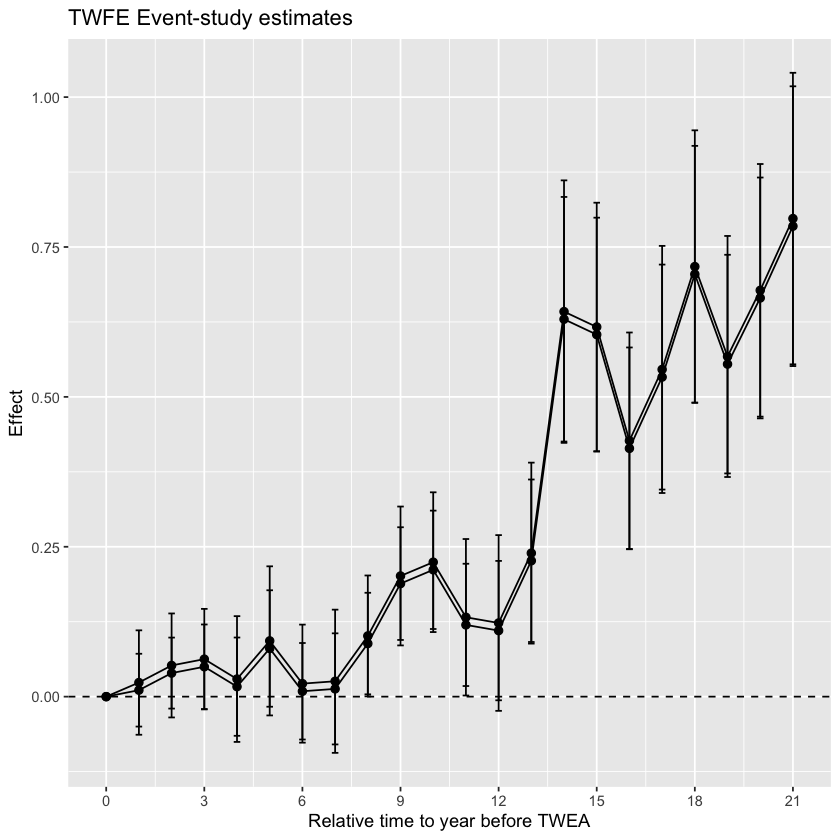

In [18]:
if (!("yearpost" %in% names(df))) {
  stop("No encuentro la variable yearpost en el .dta. Revisa el nombre en tu base.")
}

f_es_post <- as.formula(
  paste0(
    "patents ~ i(yearpost) + treatmentgroup + ",
    paste(lags, collapse = " + ")
  )
)

m_es_post <- feols(f_es_post, data = df, cluster = ~subclass)
summary(m_es_post)

tidy_post <- broom::tidy(m_es_post, conf.int = TRUE) %>%
  filter(term %in% lags) %>%
  mutate(rel_time = as.integer(str_extract(term, "\\d+"))) %>%
  arrange(rel_time)

tidy_post0 <- bind_rows(
  tibble(term = "t0", estimate = 0, conf.low = 0, conf.high = 0, rel_time = 0),
  tidy_post
) %>% arrange(rel_time)

# Comparative plot: without pre (blue) vs with pre (red)
post_from_full <- tidy_es0 %>% filter(rel_time >= 0)

p2 <- ggplot() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_line(data = tidy_post0, aes(x = rel_time, y = estimate)) +
  geom_point(data = tidy_post0, aes(x = rel_time, y = estimate), size = 2) +
  geom_errorbar(data = tidy_post0, aes(x = rel_time, ymin = conf.low, ymax = conf.high), width = 0.2) +
  geom_line(data = post_from_full, aes(x = rel_time, y = estimate), linetype = "solid") +
  geom_point(data = post_from_full, aes(x = rel_time, y = estimate), size = 2) +
  geom_errorbar(data = post_from_full, aes(x = rel_time, ymin = conf.low, ymax = conf.high), width = 0.2) +
  labs(
    title = "TWFE Event-study estimates",
    x = "Relative time to year before TWEA",
    y = "Effect"
  ) +
  scale_x_continuous(breaks = seq(0, 21, by = 3))
p2

ggsave(
  filename = "/Users/karlavega/Documents/GitHub/did_book/R/graphES_moser2.pdf",
  plot = p2, width = 8, height = 5
)



In [19]:
# did_imputation
df <- df %>% mutate(cohort = ifelse(treatmentgroup == 1, 1919L, NA_integer_))

imp <- did_imputation(
  data = df,
  yname = "patents",
  gname = "cohort",     
  tname = "year",
  idname = "subclass",
  horizon = 0:20,
  cluster_var = "subclass"
)
imp

# --- “equivalent” to having all year FEs in the regression ---
m_post_with_yearfe <- feols(
  as.formula(paste0("patents ~ i(year) + treatmentgroup + ", paste(lags, collapse = " + "))),
  data = df, cluster = ~subclass
)
summary(m_post_with_yearfe)

term,estimate,std.error,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0,0.010800656,0.03097191,-0.049904282,0.07150559
1,0.039301814,0.03020035,-0.019890874,0.09849450
2,0.049842488,0.03596747,-0.020653755,0.12033873
3,0.016649697,0.04180386,-0.065285874,0.09858527
4,0.080307105,0.04953994,-0.016791181,0.17740539
5,0.008981873,0.04104909,-0.071474339,0.08943808
6,0.012950127,0.04725654,-0.079672700,0.10557295
7,0.088553632,0.04319596,0.003889550,0.17321771
8,0.188545365,0.04793735,0.094588150,0.28250258


OLS estimation, Dep. Var.: patents
Observations: 289,920
Standard-errors: Clustered (subclass) 
                Estimate Std. Error   t value   Pr(>|t|)    
(Intercept)     0.222798   0.009341 23.852812  < 2.2e-16 ***
year::1901      0.005933   0.007753  0.765197 4.4418e-01    
year::1902      0.005933   0.008376  0.708254 4.7881e-01    
year::1903      0.034768   0.008768  3.965361 7.3990e-05 ***
year::1904      0.018488   0.008648  2.137813 3.2565e-02 *  
year::1905      0.021109   0.009063  2.329095 1.9881e-02 *  
year::1906      0.043046   0.009249  4.654055 3.3126e-06 ***
year::1907      0.101959   0.010449  9.757827  < 2.2e-16 ***
year::1908      0.058361   0.009968  5.854632 4.9894e-09 ***
year::1909      0.086783   0.010869  7.984075 1.6346e-15 ***
year::1910      0.058499   0.009813  5.961222 2.6210e-09 ***
year::1911      0.086645   0.010984  7.888430 3.5097e-15 ***
year::1912      0.109272   0.010898 10.026417  < 2.2e-16 ***
year::1913      0.068571   0.011279  6.079426 1.26

### 3.6 Undetected Linear Pretrends

This section assesses whether the results could be explained by differential linear trends not detected by standard tests.

In [20]:
# Model to obtain var-cov of pre/post coefficients with FE of treatmentgroup and year
f_pretr <- as.formula(
  paste0("patents ~ ", paste(c(leads, lags), collapse = " + "), " | treatmentgroup + year")
)
m_pretr <- feols(f_pretr, data = df, cluster = ~subclass)

# We take ONLY the first 6 pre-coefs 
leads6 <- paste0("reltimeminus", 1:6)

beta_hat <- coef(m_pretr)[leads6]
sigma_hat <- vcov(m_pretr, cluster = "subclass")[leads6, leads6, drop = FALSE]

# Relative time vector 
tVec <- -as.integer(1:6)
referencePeriod <- -1  # el periodo omitido típico en event-study (ajusta si tu omisión es otra)

# Slope para 50% power 
slope50 <- slope_for_power(
  sigma = sigma_hat,
  targetPower = 0.5,
  tVec = tVec,
  referencePeriod = referencePeriod
)
slope50



[1] 0.01291835

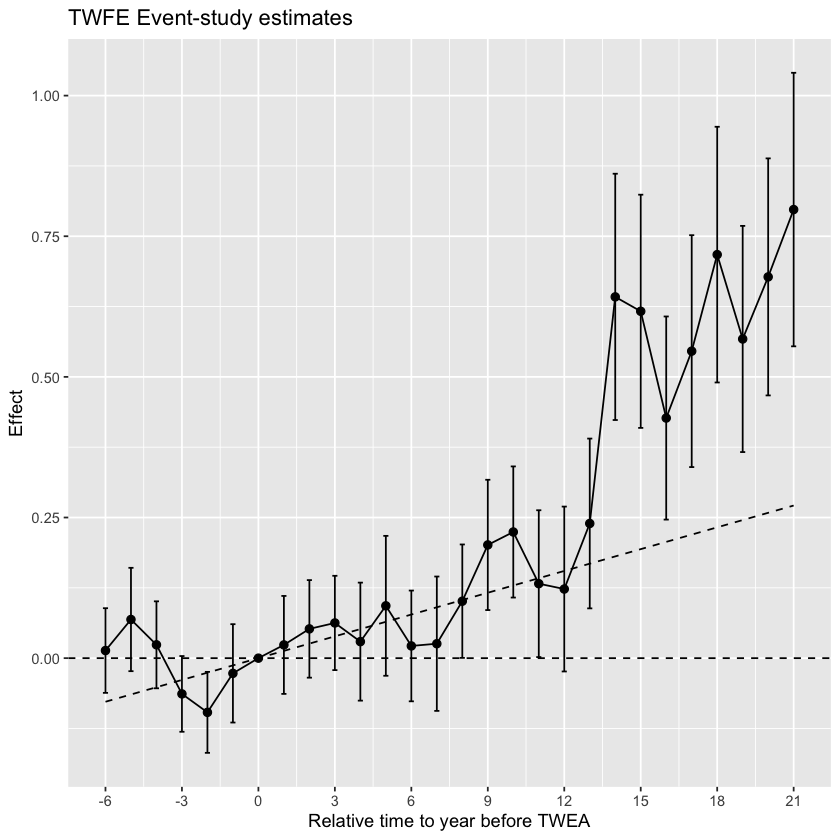

In [21]:
# For the graph with line y = slope*x

df_short <- df %>%
  filter(year >= 1912, year <= 1939) %>%
  select(-any_of(paste0("reltimeminus", 7:18)))

leads_short <- names(df_short)[str_detect(names(df_short), "^reltimeminus\\d+$")]
lags_short  <- names(df_short)[str_detect(names(df_short), "^reltimeplus\\d+$")]

m_es_short <- feols(
  as.formula(paste0(
    "patents ~ i(year) + treatmentgroup + ",
    paste(c(leads_short, lags_short), collapse = " + ")
  )),
  data = df_short, cluster = ~subclass
)

tidy_short <- broom::tidy(m_es_short, conf.int = TRUE) %>%
  filter(term %in% c(leads_short, lags_short)) %>%
  mutate(
    rel_time = case_when(
      str_detect(term, "^reltimeminus") ~ -as.integer(str_extract(term, "\\d+")),
      str_detect(term, "^reltimeplus")  ~  as.integer(str_extract(term, "\\d+"))
    )
  ) %>%
  arrange(rel_time)

tidy_short0 <- bind_rows(
  tibble(term = "t0", estimate = 0, conf.low = 0, conf.high = 0, rel_time = 0),
  tidy_short
) %>% arrange(rel_time)

p3 <- ggplot(tidy_short0, aes(x = rel_time, y = estimate)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_line() +
  geom_point(size = 2) +
  geom_errorbar(aes(ymin = conf.low, ymax = conf.high), width = 0.2) +
  geom_function(fun = function(x) slope50 * x, linetype = "dashed") +
  labs(
    title = "TWFE Event-study estimates",
    x = "Relative time to year before TWEA",
    y = "Effect"
  ) +
  scale_x_continuous(breaks = seq(-6, 21, by = 3))
p3

ggsave(
  filename = "/Users/karlavega/Documents/GitHub/did_book/R/graphES_moser3.pdf",
  plot = p3, width = 8, height = 5
)

### 3.7 Variance of the long-term effect

The variance of the results between groups is compared 14 years after treatment.

In [22]:
df_1932 <- df %>% filter(year == 1932)

sd_treated  <- sd(df_1932$diffpatentswrt1918[df_1932$treatmentgroup == 1], na.rm = TRUE)
sd_control  <- sd(df_1932$diffpatentswrt1918[df_1932$treatmentgroup == 0], na.rm = TRUE)

sd_effects <- sd_treated - sd_control
sd_effects

m_sd <- lm(diffpatentswrt1918 ~ treatmentgroup, data = df_1932)
b <- coef(m_sd)["treatmentgroup"]

ci_manual <- c(lower = b - 1.96 * sd_effects, upper = b + 1.96 * sd_effects)
ci_manual

# formal test of equality of variances (F-test):
var_test_1932 <- var.test(
  diffpatentswrt1918 ~ factor(treatmentgroup),
  data = df_1932
)
var_test_1932

[1] 0.2390978

lower.treatmentgroup upper.treatmentgroup 
           0.1735848            1.1108481


	F test to compare two variances

data:  diffpatentswrt1918 by factor(treatmentgroup)
F = 0.77644, num df = 6911, denom df = 335, p-value = 0.0008145
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 0.6610919 0.9018686
sample estimates:
ratio of variances 
         0.7764403 


### 3.8 Placebo tests

Placebo tests are performed to assess spurious heterogeneity before treatment.

In [23]:
years_loop <- 1900:1939

placebo_var_tests <- map_dfr(years_loop, function(y) {
  d <- df %>% filter(year == y)
  
# If a year does not have both cells, return NA
  ok <- all(c(0,1) %in% d$treatmentgroup) &&
    sum(d$treatmentgroup == 0, na.rm=TRUE) > 1 &&
    sum(d$treatmentgroup == 1, na.rm=TRUE) > 1
  
  if (!ok) {
    return(tibble(year = y, p_value = NA_real_))
  }
  
  vt <- var.test(diffpatentswrt1918 ~ factor(treatmentgroup), data = d)
  tibble(year = y, p_value = vt$p.value)
})

placebo_var_tests

year,p_value
<int>,<dbl>
1900,0.000000e+00
1901,0.000000e+00
1902,0.000000e+00
1903,0.000000e+00
1904,0.000000e+00
1905,0.000000e+00
1906,0.000000e+00
1907,3.621992e-11
1908,0.000000e+00


## Chapter 4 — Extensions to the Basic DiD Model

This chapter extends the basic DiD estimators to address:

- baseline covariate control,
- interactive fixed effects,
- synthetic control methods,
- sensitivity analysis to pretrend violations.

In [24]:
library(dplyr)
library(stringr)
library(purrr)
library(fixest)
library(broom)
library(ggplot2)
library(fect)
library(DIDmultiplegtDYN)   # did_multiplegt_dyn
library(synthdid)          # SDID
# install.packages("remotes"); remotes::install_github("ebenmichael/augsynth")
library(augsynth)          # SC / ASCM
library(HonestDiD)

Warning message in rgl.init(initValue, onlyNULL):
“X11 error: GLXBadContext”
Warning message:
“'rgl.init' failed, will use the null device.
See '?rgl.useNULL' for ways to avoid this warning.”


In [25]:
# ------------------------------------------------------------------
# Helpers:
# ------------------------------------------------------------------
leads <- names(df)[str_detect(names(df), "^reltimeminus\\d+$")]
lags  <- names(df)[str_detect(names(df), "^reltimeplus\\d+$")]

# For “res_post” (TWFE post only), we regenerate it here with fixest:
m_twfe_post <- feols(
  as.formula(paste0("patents ~ i(year) + treatmentgroup + ", paste(lags, collapse = " + "))),
  data = df, cluster = ~subclass
)

res_post <- broom::tidy(m_twfe_post, conf.int = TRUE) %>%
  filter(term %in% lags) %>%
  transmute(
    t = as.integer(str_extract(term, "\\d+")),
    att = estimate,
    lo  = conf.low,
    hi  = conf.high
  ) %>%
  arrange(t)

### 4.1 Estimators with Controls

Stata absorbs `year#patents1900` (time-varying slope on a baseline covariate). In R, the most direct equivalent is interacting the baseline covariate with year using `i(year, patents1900)`.


OLS estimation, Dep. Var.: patents
Observations: 289,920
Fixed-effects: treatmentgroup: 2,  year: 40
Varying slopes: patents1900 (year): 40
Standard-errors: Clustered (subclass) 
                Estimate Std. Error   t value   Pr(>|t|)    
reltimeminus1  -0.025368   0.044435 -0.570904 5.6808e-01    
reltimeminus2  -0.069494   0.037167 -1.869778 6.1555e-02 .  
reltimeminus3  -0.052456   0.034976 -1.499768 1.3372e-01    
reltimeminus4   0.025145   0.039748  0.632609 5.2701e-01    
reltimeminus5   0.034340   0.044936  0.764205 4.4477e-01    
reltimeminus6  -0.002947   0.037364 -0.078886 9.3713e-01    
reltimeminus7   0.001021   0.050468  0.020227 9.8386e-01    
reltimeminus8   0.008868   0.047465  0.186832 8.5180e-01    
reltimeminus9  -0.019761   0.041489 -0.476296 6.3388e-01    
reltimeminus10  0.013616   0.046739  0.291324 7.7081e-01    
reltimeminus11 -0.073838   0.058593 -1.260179 2.0765e-01    
reltimeminus12 -0.003363   0.040788 -0.082453 9.3429e-01    
reltimeminus13  0.014110   0

[1] NA

OLS estimation, Dep. Var.: patents1900
Observations: 7,248
Standard-errors: IID 
                Estimate Std. Error  t value  Pr(>|t|)    
(Intercept)     0.221788   0.009315 23.81040 < 2.2e-16 ***
treatmentgroup -0.156312   0.043262 -3.61311 0.0003046 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 0.774308   Adj. R2: 0.001661

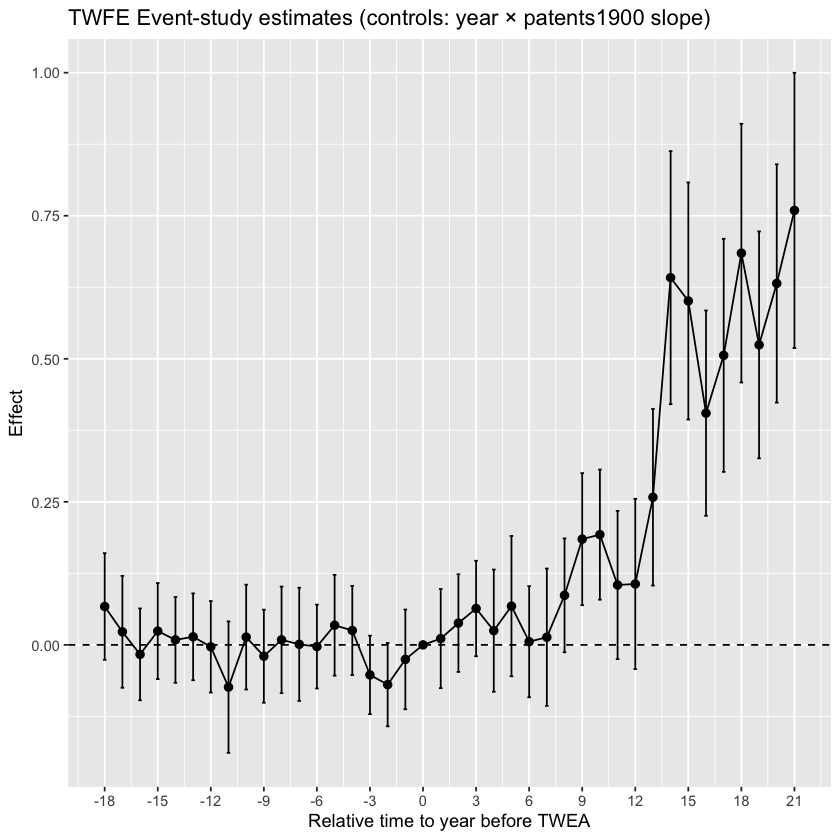

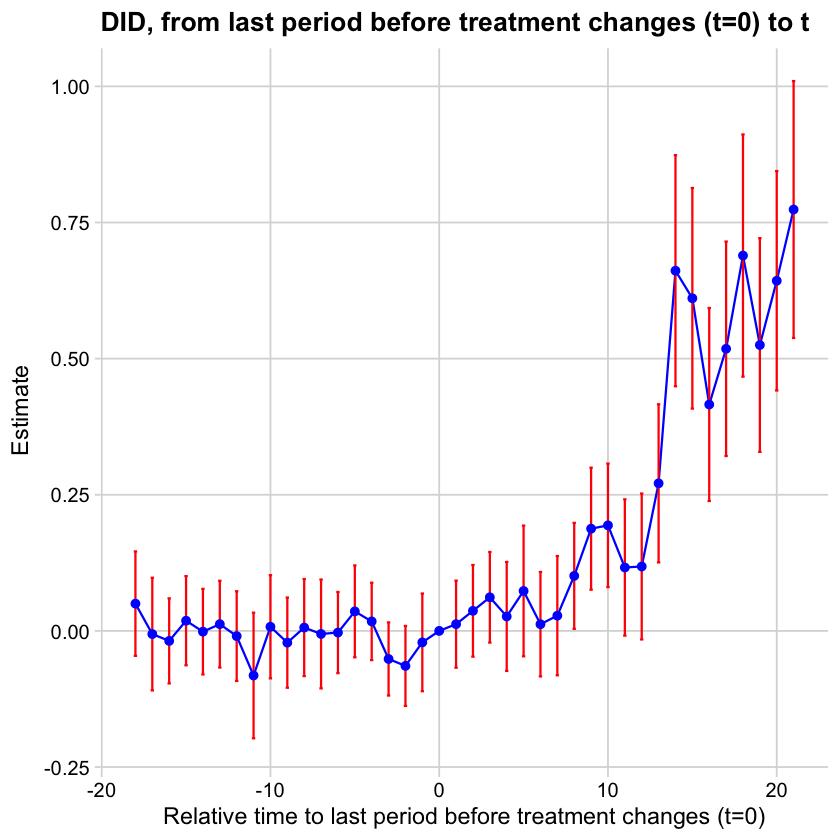

In [26]:
m_ctrl <- feols(
  as.formula(paste0("patents ~ ", paste(c(leads, lags), collapse = " + "), " | treatmentgroup + year[patents1900]")),
  data = df,
  cluster = ~subclass
)
summary(m_ctrl)

# Joint test pre-trends (Stata: test reltimeminus1 ... reltimeminus18)
wald_ctrl_pre <- wald(m_ctrl, paste(leads, collapse = " = 0, "), cluster = "subclass")
wald_ctrl_pre

# Event-study plot with controls
tidy_ctrl <- broom::tidy(m_ctrl, conf.int = TRUE) %>%
  filter(term %in% c(leads, lags)) %>%
  mutate(
    rel_time = case_when(
      str_detect(term, "^reltimeminus") ~ -as.integer(str_extract(term, "\\d+")),
      str_detect(term, "^reltimeplus")  ~  as.integer(str_extract(term, "\\d+"))
    )
  ) %>%
  arrange(rel_time)

tidy_ctrl0 <- bind_rows(
  tibble(term = "t0", estimate = 0, conf.low = 0, conf.high = 0, rel_time = 0),
  tidy_ctrl
) %>% arrange(rel_time)

p_ctrl <- ggplot(tidy_ctrl0, aes(x = rel_time, y = estimate)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_line() +
  geom_point(size = 2) +
  geom_errorbar(aes(ymin = conf.low, ymax = conf.high), width = 0.2) +
  labs(
    title = "TWFE Event-study estimates (controls: year × patents1900 slope)",
    x = "Relative time to year before TWEA",
    y = "Effect"
  ) +
  scale_x_continuous(breaks = seq(-18, 21, by = 3))
p_ctrl

ggsave(
  "/Users/karlavega/Documents/GitHub/did_book/R/graphES_moser_controls.pdf",
  p_ctrl, width = 8, height = 5
)

# Testing that treatmentgroup and covariate correlate 
m_corr <- feols(patents1900 ~ treatmentgroup, data = df %>% filter(year == 1900), vcov = "iid")
summary(m_corr)

# DIDmultiplegtDYN 

library(DIDmultiplegtDYN)

did_dyn_ctrl <- did_multiplegt_dyn(
  df,
  outcome   = "patents",
  group     = "subclass",
  time      = "year",
  treatment = "twea",
  effects   = 21,
  placebo   = 18,
  trends_nonparam = "patents1900"
)

### 4.2 Interactive Fixed Effects

Best R equivalent is the **fect** package (Xu) which implements interactive fixed effects / generalized synthetic control and related estimators.


In [ ]:
set.seed(1)

# fect wait long panel with unit/time. In staggered conditions, it usually works with:

ife_fit <- fect(
  data  = df,
  Y     = "patents",
  D     = "twea",
  index = c("subclass","year"),
  method = "ife",
  r = 2,            
  se = TRUE,
  nboots = 200,     
  tol = 1e-4
)

# ATTs dinámicos 

if (is.null(ife_fit$est.att)) {
  stop("I can't find ife_fit$est.att. Check str(ife_fit) to locate the effects table.")
}

att_mat <- ife_fit$est.att  

ife_es <- as.data.frame(att_mat) %>%
  mutate(
    h = as.integer(rownames(att_mat))
  ) %>%
  filter(h >= 1, h <= 21) %>%
  transmute(
    t   = h,
    att = ATT,
    lo  = CI.lower,
    hi  = CI.upper
  )



p_ife <- ggplot() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_line(data = ife_es, aes(x = t, y = att)) +
  geom_point(data = ife_es, aes(x = t, y = att), size = 2) +
  geom_errorbar(data = ife_es, aes(x = t, ymin = lo, ymax = hi), width = 0.2) +
  geom_line(data = res_post, aes(x = t, y = att), linetype = "solid") +
  geom_point(data = res_post, aes(x = t, y = att), size = 2) +
  geom_errorbar(data = res_post, aes(x = t, ymin = lo, ymax = hi), width = 0.2) +
  labs(title = "Event-study estimates", x = "Years after TWEA", y = "Effect") +
  scale_x_continuous(breaks = seq(1, 21, by = 5))
p_ife

ggsave(
  "/Users/karlavega/Documents/GitHub/did_book/R/graphES_moser_ife_did.pdf",
  p_ife, width = 8, height = 5
)

Parallel computing ...




### 4.3 Synthetic Control

Stata uses `sdid_event ... method("sc")`. In R, the closest "classic" synthetic control workflow is the **Synth** package (Abadie et al.). This requires defining a single treated unit (or aggregating treated units) and specifying pre-period predictors.


In [ ]:
set.seed(1)

# Augsynth typically needs:
# outcome ~ treat | unit + time
# and uses inference by bootstrap/Jackknife+ (depending on available functions).
sc_fit <- augsynth(
  patents ~ twea,
  unit = subclass,
  time = year,
  data = df,
  progfunc = "None",      
  scm = TRUE
)
summary(sc_fit)

# Dynamic curve (years post): Augsynth usually provides path/att by time.
# Extract series with predict() (may vary):

sc_att <- tryCatch({
# Some methods: att <- sc_fit$att; or predict(sc_fit, ...) depending on the version
  out <- sc_fit$att
  if (is.null(out)) stop("No sc_fit$att")
  out
}, error = function(e) NULL)

# If sc_att is NULL, check str(sc_fit) and take the equivalent component.
if (!is.null(sc_att)) {
# Convert to horizon 1..21 if applicable (adjust index according to your data)
  sc_es <- tibble(t = 1:length(sc_att), att = as.numeric(sc_att)) %>%
    filter(t <= 21)
  
  p_sc <- ggplot() +
    geom_hline(yintercept = 0, linetype = "dashed") +
    geom_line(data = sc_es, aes(x = t, y = att)) +
    geom_point(data = sc_es, aes(x = t, y = att), size = 2) +
    geom_line(data = res_post, aes(x = t, y = att)) +
    geom_point(data = res_post, aes(x = t, y = att), size = 2) +
    labs(title = "Event-study estimates", x = "Years after TWEA", y = "Effect") +
    scale_x_continuous(breaks = seq(1, 21, by = 5))
  p_sc
  
  ggsave(
    "/Users/karlavega/Documents/GitHub/did_book/R/graphES_moser_sc_did.pdf",
    p_sc, width = 8, height = 5
  )
}

# Demeaned 
df <- df %>%
  group_by(subclass) %>%
  mutate(pre_mean = mean(patents[year <= 1918], na.rm = TRUE)) %>%
  ungroup() %>%
  mutate(patents_demeaned = patents - pre_mean)

sc_fit_dm <- augsynth(
  patents_demeaned ~ twea,
  unit = subclass,
  time = year,
  data = df,
  progfunc = "None",
  scm = TRUE
)
summary(sc_fit_dm)

### 4.4 Synthetic DiD

DiD and synthetic control are combined into a single estimator.

In [ ]:
# synthdid works in matrix format: Y(N x T) and W(N x T), ordered by unit/time.
# We construct matrices:

df_mat <- df %>%
  arrange(subclass, year)

Y <- df_mat %>%
  select(subclass, year, patents) %>%
  tidyr::pivot_wider(names_from = year, values_from = patents) %>%
  select(-subclass) %>%
  as.matrix()

W <- df_mat %>%
  select(subclass, year, twea) %>%
  tidyr::pivot_wider(names_from = year, values_from = twea) %>%
  select(-subclass) %>%
  as.matrix()

# SDID estimation (average post-ATT). 
sdid_est <- synthdid_estimate(Y, W)
sdid_curve <- synthdid_effect_curve(sdid_est)  

# We took the first 21 posts
sd_es <- tibble(t = seq_along(sdid_curve), att = as.numeric(sdid_curve)) %>%
  filter(t >= 1, t <= 21)

p_sdid <- ggplot() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_line(data = sd_es, aes(x = t, y = att)) +
  geom_point(data = sd_es, aes(x = t, y = att), size = 2) +
  geom_line(data = res_post, aes(x = t, y = att)) +
  geom_point(data = res_post, aes(x = t, y = att), size = 2) +
  labs(title = "Event-study estimates", x = "Years after TWEA", y = "Effect") +
  scale_x_continuous(breaks = seq(1, 21, by = 5))
p_sdid

ggsave(
  "/Users/karlavega/Documents/GitHub/did_book/R/graphES_moser_sd_did.pdf",
  p_sdid, width = 8, height = 5
)

### 4.5 Sensitivity Analysis (Rambachan and Roth)

The robustness of the estimated effects is evaluated in the face of potential violations of pre-trends.

In [ ]:
m_es_rr <- feols(
  as.formula(paste0("patents ~ ", paste(c(leads, lags), collapse = " + "), " | year + treatmentgroup")),
  data = df, cluster = ~subclass
)

# Order betahat: pre (1..18) then post (1..21)
betahat <- c(coef(m_es_rr)[leads], coef(m_es_rr)[lags])
Sigma   <- vcov(m_es_rr, cluster = "subclass")[c(leads, lags), c(leads, lags), drop = FALSE]

numPre  <- length(leads)   # 18
numPost <- length(lags)    # 21

# l_vec in Stata selects horizon 14 (here: post #14)
l_vec <- rep(0, numPost)
l_vec[14] <- 1

# Sensitivity for mvec 0.5..2
mvec <- seq(0.5, 2, by = 0.5)

sens_res <- createSensitivityResults(
  betahat = betahat,
  sigma   = Sigma,
  numPrePeriods  = numPre,
  numPostPeriods = numPost,
  method = "C-LF",  
  Mvec = mvec,
  l_vec = l_vec
)
sens_res
# Coefplot style plot
plot(sens_res)

# --- Rambachan and Roth using β_fe,-1 and β_fe,1

df_3y <- df %>% filter(year %in% c(1918, 1904, 1932))

m_rr2 <- feols(
  patents ~ reltimeminus14 + reltimeplus14 | year + treatmentgroup,
  data = df_3y, cluster = ~subclass
)

betahat2 <- c(coef(m_rr2)["reltimeminus14"], coef(m_rr2)["reltimeplus14"])
Sigma2   <- vcov(m_rr2, cluster = "subclass")[c("reltimeminus14","reltimeplus14"),
                                              c("reltimeminus14","reltimeplus14"),
                                              drop = FALSE]

# 1 pre, 1 post
sens_res2 <- createSensitivityResults(
  betahat = betahat2,
  sigma   = Sigma2,
  numPrePeriods  = 1,
  numPostPeriods = 1,
  method = "C-LF",
  Mvec = seq(2, 10, by = 2),
  l_vec = 1
)
plot(sens_res2)

ggsave(
  "/Users/karlavega/Documents/GitHub/did_book/R/coefplot.pdf",
  width = 8, height = 5
)


## Chapter 5 — TWFE and Weight Decomposition

This chapter examines how TWFE estimators combine comparisons between units and periods, using data from **Gentzkow et al. (2011)**.

Before we begin, we load the database corresponding to this chapter.

In [ ]:
library(haven)
library(dplyr)
library(fixest)
library(TwoWayFEWeights)


dfg <- read_dta("/Users/karlavega/Documents/GitHub/did_book/cc_xd_didtextbook_2025_9_30/Data sets/gentzkow et al 2011/gentzkowetal_didtextbook.dta") %>%
  mutate(
    year   = as.integer(year),
    cnty90 = as.factor(cnty90),
    styr   = as.factor(styr)
  )


### 5.1 TWFE Regression

A standard TWFE model is estimated and the estimator is decomposed into its implicit weights.

In [ ]:
m_twfe <- feols(prestout ~ i(year) + numdailies | cnty90, data = dfg, cluster = ~cnty90)
summary(m_twfe)

# Decomposition 
decomp_twfe <- twowayfeweights(
  data = dfg,
  Y = "prestout",
  G = "cnty90",
  T = "year",
  D = "numdailies",
  type = "feTR"
)
decomp_twfe

### 5.2 TWFE with State-Specific Trends

Each state is allowed to have its own temporal trend, controlling for unobserved heterogeneity.

In [ ]:
m_twfe_styr <- feols(prestout ~ numdailies | cnty90 + year + styr, data = dfg, cluster = ~cnty90)
coeftable(m_twfe_styr)["numdailies", c("Estimate","Std. Error")]

# Decomposition with "controls"
styr_mm <- model.matrix(~ 0 + styr, data = dfg)              
colnames(styr_mm) <- paste0("styr", seq_len(ncol(styr_mm)))  

dfg2 <- bind_cols(dfg, as.data.frame(styr_mm))
styr_controls <- colnames(styr_mm)

decomp_twfe_styr <- twowayfeweights(
  data = dfg2,
  Y = "prestout",
  G = "cnty90",
  T = "year",
  D = "numdailies",
  type = "feTR",
  controls = styr_controls
)
decomp_twfe_styr

### 5.3 First Difference Regression

The model is estimated using first differences with specific trends, and the estimator weights are re-analyzed.

In [ ]:
m_fd <- feols(changeprestout ~ changedailies | styr, data = dfg, cluster = ~cnty90)
summary(m_fd)

# Decomposition 
decomp_fd <- twowayfeweights(
  data = dfg2,
  Y = "changeprestout",
  G = "cnty90",
  T = "year",
  D = "changedailies",
  type = "fdTR",
  D0 = "numdailies",
  controls = styr_controls
)
decomp_fd

# Test random weights 
decomp_fd_test <- twowayfeweights(
  data = dfg2,
  Y = "changeprestout",
  G = "cnty90",
  T = "year",
  D = "changedailies",
  type = "fdTR",
  D0 = "numdailies",
  controls = styr_controls,
  test_random_weights = "year"
)
decomp_fd_test


## Chapter 6 — Multiple Cohorts and Alternative Estimators

This chapter analyzes data with **stepwise treatments** and compares different Difference-in-Differences estimators proposed in the recent literature.

Before starting, the database used in this chapter is loaded.

In [ ]:
library(haven)
library(dplyr)
library(stringr)
library(fixest)
library(broom)
library(car)
library(TwoWayFEWeights)
library(did)
library(DIDmultiplegtDYN)
library(didimputation)

dfw <- read_dta("/Users/karlavega/Documents/GitHub/did_book/cc_xd_didtextbook_2025_9_30/Data sets/Wolfers 2006/wolfers2006_didtextbook.dta") %>%
  mutate(
    state = as.factor(state),
    year  = as.integer(year)
  )

# Helpers:
rel_time_vars <- names(dfw)[str_detect(names(dfw), "^rel_time\\d+$")]
pre_vars      <- names(dfw)[str_detect(names(dfw), "^rel_timeminus\\d+$")]

### 6.1 Static TWFE Regression

A standard TWFE model with fixed effects per state and year is estimated,
weighted by state population.

In [ ]:
m_static <- feols(
  div_rate ~ udl | state + year,
  data = dfw,
  weights = ~stpop,
  cluster = ~state
)
summary(m_static)

### 6.2 Decomposition of the TWFE estimator

The implicit weights of the TWFE estimator are analyzed and it is assessed whether they are correlated with the duration of exposure.

In [ ]:
decomp_static <- twowayfeweights(
  data = dfw,
  Y = "div_rate",
  G = "state",
  T = "year",
  D = "udl",
  type = "feTR",
  weight = "stpop",
  test_random_weights = "exposurelength"
)
decomp_static

### 6.3 Test of randomization in treatment timing

This assesses whether the timing of treatment initiation can be considered exogenous.

In [ ]:
m_timing <- feols(
  div_rate ~ i(early_late_never) ,
  data = dfw %>% filter(cohort != 1956, year <= 1968),
  weights = ~stpop,
  cluster = ~state
)
summary(m_timing)

### 6.4 Event-study TWFE

Dynamic effects are estimated using an event-study TWFE and pre-trends are tested.

In [ ]:
f_es <- as.formula(
  paste0("div_rate ~ ", paste(rel_time_vars, collapse = " + "), " | state + year")
)

m_es <- feols(
  f_es,
  data = dfw,
  weights = ~stpop,
  cluster = ~state
)
etable(m_es)

# Joint test de pre-trends 
pre9 <- paste0("rel_timeminus", 1:9)
pre9 <- pre9[pre9 %in% names(dfw)]  

wald_pre9 <- wald(m_es, paste(pre9, collapse = " = 0, "), cluster = "state")
wald_pre9


### 6.5 Decomposition of the First Dynamic Effect

The first coefficient of the event study is decomposed
to analyze which comparisons identify it.

In [ ]:
other_tr <- paste0("rel_time", 2:16)
other_tr <- other_tr[other_tr %in% names(dfw)]

controls_pre <- paste0("rel_timeminus", 1:9)
controls_pre <- controls_pre[controls_pre %in% names(dfw)]

decomp_es1 <- twowayfeweights(
  data = dfw,
  Y = "div_rate",
  G = "state",
  T = "year",
  D = "rel_time1",
  type = "feTR",
  weight = "stpop",
  test_random_weights = "year",
  other_treatments = other_tr,
  controls = controls_pre
)
decomp_es1

### 6.6 Sun and Abraham (2021) Estimator

A robust event study is estimated for stepped treatments using adoption cohorts.

In [ ]:
dfw_sa <- dfw %>%
  mutate(cohort_sa = ifelse(cohort == 0, NA_integer_, as.integer(cohort)))

# sunab(g, t): 
m_sa <- feols(
  div_rate ~ sunab(cohort_sa, year) | state + year,
  data = dfw_sa,
  weights = ~stpop,
  cluster = ~state
)
summary(m_sa)

### 6.7 Callaway and Sant’Anna (2021) Estimator

Dynamic average effects are estimated by cohort using untreated groups as controls.

In [ ]:
dfw_cs <- dfw %>%
  mutate(cohort_cs = ifelse(is.na(cohort), 0L, as.integer(cohort)))

attgt <- att_gt(
  yname = "div_rate",
  tname = "year",
  idname = "state",
  gname = "cohort_cs",
  data = dfw_cs,
  control_group = "notyettreated",
  weightsname = "stpop",
  clustervars = "state"
)

agg_event <- aggte(attgt, type = "dynamic")
summary(agg_event)

### 6.8 Estimador de de Chaisemartin y D’Haultfoeuille

Se estiman efectos dinámicos permitiendo heterogeneidad entre cohortes y a lo largo del tiempo.

In [ ]:
dc_dh <- did_multiplegt_dyn(
  dfw,
  Y = "div_rate",
  G = "state",
  T = "year",
  D = "udl",
  effects = 16,
  placebo = 9,
  weights = "stpop"
)
dc_dh

### 6.9 Estimador de Borusyak et al. (2021)

Se estima el efecto dinámico usando imputación bajo supuestos de tendencias paralelas.


In [ ]:
dfw_bjs <- dfw %>%
  mutate(cohort_bjs = ifelse(cohort == 0, NA_integer_, as.integer(cohort)))

bjs <- did_imputation(
  data = dfw_bjs,
  yname = "div_rate",
  gname = "cohort_bjs",
  tname = "year",
  idname = "state",
  horizon = 0:15,
  pretrends = 9,
  weightsname = "stpop",
  cluster_var = "state"
)
bjs

## Chapter 7 — Continuous Treatments and Robustness Tests

This chapter analyzes DiD estimators with continuous treatment (ntrgap) and studies various pre-trend and robustness tests, using data from Pierce and Schott (2016).

Before starting, the database corresponding to this chapter is loaded.

In [ ]:
library(haven)
library(dplyr)
library(stringr)
library(tidyr)
library(estimatr)
library(TwoWayFEWeights)
library(StuteTest)

dfp <- read_dta("/Users/karlavega/Documents/GitHub/did_book/cc_xd_didtextbook_2025_9_30/Data sets/Pierce and Schott 2016/pierce_schott_didtextbook.dta") %>%
  mutate(indusid = as.factor(indusid))

### 7.1 TWFE Regressions

Simple TWFE regressions are estimated for different years, treating the NTR gap as a continuous treatment.

In [ ]:
m_2001 <- lm_robust(delta2001 ~ ntrgap, data = dfp, se_type = "HC2")
m_2002 <- lm_robust(delta2002 ~ ntrgap, data = dfp, se_type = "HC2")
m_2004 <- lm_robust(delta2004 ~ ntrgap, data = dfp, se_type = "HC2")
m_2005 <- lm_robust(delta2005 ~ ntrgap, data = dfp, se_type = "HC2")

m_2001; m_2002; m_2004; m_2005

### 7.2 Weight Analysis

The implicit weights of the estimator are analyzed when the treatment is continuous.

In [ ]:
if (!("cons" %in% names(dfp))) dfp <- dfp %>% mutate(cons = 1)

w_fd <- twowayfeweights(
  data = dfp,
  Y = "delta2001",
  G = "indusid",
  T = "cons",
  D = "ntrgap",
  type = "fdTR",
  D0 = "ntrgap"
)
w_fd

### 7.3 Treatment Randomization Test

This test assesses whether the NTR gap is correlated with pre-treatment characteristics.


In [ ]:
m_rand <- lm_robust(
  ntrgap ~ lemp1997 + lemp1998 + lemp1999 + lemp2000,
  data = dfp,
  se_type = "HC2"
)
m_rand

### 7.4 Stute Test

The non-parametric Stute test is implemented to evaluate the validity of the DiD design.

In [ ]:
set.seed(1)
st_2001 <- stute_test(Y = dfp$delta2001, D = dfp$ntrgap, seed = 1)
st_2002 <- stute_test(Y = dfp$delta2002, D = dfp$ntrgap, seed = 1)
st_2004 <- stute_test(Y = dfp$delta2004, D = dfp$ntrgap, seed = 1)
st_2005 <- stute_test(Y = dfp$delta2005, D = dfp$ntrgap, seed = 1)

st_2001; st_2002; st_2004; st_2005

# Joint test 
df_long <- dfp %>%
  pivot_longer(
    cols = matches("^(delta|deltalintrend)\\d{4}$"),
    names_to = c(".value", "year"),
    names_pattern = "^(delta|deltalintrend)(\\d{4})$"
  ) %>%
  mutate(year = as.integer(year))

df_long_post <- df_long %>% filter(year >= 2001)

# Panel-mode Stute test con (Y, D, G, T). 
st_joint_post <- stute_test(
  Y = df_long_post$delta,
  D = df_long_post$ntrgap,
  G = df_long_post$indusid,
  T = df_long_post$year,
  seed = 1
)
st_joint_post

# Test that quasi stayers 
x <- sort(dfp$ntrgap)
stat_test_qs <- x[1] / (x[2] - x[1])
stat_test_qs


### 7.5 Pre-trend (linear) tests

Differences in trends are evaluated before treatment.


In [ ]:
m_pre_1999 <- lm_robust(delta1999 ~ ntrgap, data = dfp, se_type = "HC2")
m_pre_1998 <- lm_robust(delta1998 ~ ntrgap, data = dfp, se_type = "HC2")
m_pre_1997 <- lm_robust(delta1997 ~ ntrgap, data = dfp, se_type = "HC2")

m_pre_1999; m_pre_1998; m_pre_1997

### 7.6 Pre-trends with industry-specific trends

Industry-specific linear trends are permitted, both in parametric and non-parametric form.

In [ ]:
m_lt_1998 <- lm_robust(deltalintrend1998 ~ ntrgap, data = dfp, se_type = "HC2")
m_lt_1997 <- lm_robust(deltalintrend1997 ~ ntrgap, data = dfp, se_type = "HC2")
m_lt_1998; m_lt_1997

st_lt_1998_np <- stute_test(Y = dfp$deltalintrend1998, D = dfp$ntrgap, order = 0, seed = 1)
st_lt_1997_np <- stute_test(Y = dfp$deltalintrend1997, D = dfp$ntrgap, order = 0, seed = 1)
st_lt_1998_np; st_lt_1997_np

df_long_pre <- df_long %>% filter(year <= 1998)

st_joint_pre_np <- stute_test(
  Y = df_long_pre$deltalintrend,
  D = df_long_pre$ntrgap,
  G = df_long_pre$indusid,
  T = df_long_pre$year,
  order = 0,
  seed = 1
)
st_joint_pre_np

### 7.7 Stute Test with Linear Trends (Post)

The robustness of the post-treatment effects is evaluated, allowing for linear trends.

In [ ]:
st_post_2001 <- stute_test(Y = dfp$deltalintrend2001, D = dfp$ntrgap, seed = 1)
st_post_2002 <- stute_test(Y = dfp$deltalintrend2002, D = dfp$ntrgap, seed = 1)
st_post_2004 <- stute_test(Y = dfp$deltalintrend2004, D = dfp$ntrgap, seed = 1)
st_post_2005 <- stute_test(Y = dfp$deltalintrend2005, D = dfp$ntrgap, seed = 1)

st_post_2001; st_post_2002; st_post_2004; st_post_2005

df_long_post2 <- df_long %>% filter(year >= 2001)

st_joint_post_lt <- stute_test(
  Y = df_long_post2$deltalintrend,
  D = df_long_post2$ntrgap,
  G = df_long_post2$indusid,
  T = df_long_post2$year,
  seed = 1
)
st_joint_post_lt

### 7.8 Estimators with Linear Trends

Effects are estimated by explicitly allowing
linear trends by industry.

In [ ]:
m_lt_2001 <- lm_robust(deltalintrend2001 ~ ntrgap, data = dfp, se_type = "HC2")
m_lt_2002 <- lm_robust(deltalintrend2002 ~ ntrgap, data = dfp, se_type = "HC2")
m_lt_2004 <- lm_robust(deltalintrend2004 ~ ntrgap, data = dfp, se_type = "HC2")
m_lt_2005 <- lm_robust(deltalintrend2005 ~ ntrgap, data = dfp, se_type = "HC2")

m_lt_2001; m_lt_2002; m_lt_2004; m_lt_2005

## Chapter 8 — Dynamics with Lagged Treatments

This chapter examines DiD models with **dynamic treatments** and **lagged effects**, again using data from **Gentzkow et al. (2011)**.

The previously used database is reloaded to ensure a clean environment before estimations.

In [ ]:
library(haven)
library(dplyr)
library(fixest)
library(TwoWayFEWeights)
library(DIDmultiplegtDYN)


dfg <- read_dta("/Users/karlavega/Documents/GitHub/did_book/cc_xd_didtextbook_2025_9_30/Data sets/gentzkow et al 2011/gentzkowetal_didtextbook.dta") %>%
  mutate(
    year   = as.integer(year),
    cnty90 = as.factor(cnty90),
    styr   = as.factor(styr)
  )

### 8.1 Is the change in newspapers as-good-as-random?

We evaluate whether the change in the number of newspapers can be considered exogenous, conditional on lagged variables.

In [ ]:
m_rand1 <- feols(changedailies ~ lag_numdailies, data = dfg, cluster = ~cnty90)
m_rand2 <- feols(changedailies ~ lag_ishare_urb, data = dfg, cluster = ~cnty90)
etable(m_rand1, m_rand2)

### 8.2 TWFE with lagged treatments

A TWFE model is estimated that includes both the contemporaneous treatment and its lag.

In [ ]:
m_dlag <- feols(prestout ~ i(year) + numdailies + lag_numdailies | cnty90,
                data = dfg, cluster = ~cnty90)
etable(m_dlag)

# Decomposition 
# 1) Decompose numdailies coefficients controlling for lag_numdailies
decomp_num <- twowayfeweights(
  data = dfg,
  Y = "prestout",
  G = "cnty90",
  T = "year",
  D = "numdailies",
  type = "feTR",
  other_treatments = "lag_numdailies"
)
decomp_num

# 2) Decompose the lag_num coefficient of dailies controlled by the number of dailies
decomp_lag <- twowayfeweights(
  data = dfg,
  Y = "prestout",
  G = "cnty90",
  T = "year",
  D = "lag_numdailies",
  type = "feTR",
  other_treatments = "numdailies"
)
decomp_lag

### 8.3 Unnormalized Event Study

Unnormalized dynamic effects are estimated using the Chaisemartin and D’Haultfoeuille estimator.

In [ ]:
dcdh_non_norm <- did_multiplegt_dyn(
  data    = dfg,
  Y       = "prestout",
  G       = "cnty90",
  T       = "year",
  D       = "numdailies",
  effects = 4,
  placebo = 4,
  effects_equal = "all"
)
dcdh_non_norm

### 8.4 Trajectory Decomposition

The individual trajectories that make up the unnormalized average effects are analyzed.

In [ ]:
dcdh_design_1 <- did_multiplegt_dyn(
  data = dfg, Y="prestout", G="cnty90", T="year", D="numdailies",
  effects = 1,
  design = 0.8, design_print = TRUE
)
dcdh_design_2 <- did_multiplegt_dyn(
  data = dfg, Y="prestout", G="cnty90", T="year", D="numdailies",
  effects = 2,
  design = 0.8, design_print = TRUE
)
dcdh_design_4 <- did_multiplegt_dyn(
  data = dfg, Y="prestout", G="cnty90", T="year", D="numdailies",
  effects = 4,
  design = 0.8, design_print = TRUE
)

### 8.5 Normalized Event Study

Dynamic effects are normalized to facilitate interpretation and comparison between periods.

In [ ]:
dcdh_norm <- did_multiplegt_dyn(
  data    = dfg,
  Y       = "prestout",
  G       = "cnty90",
  T       = "year",
  D       = "numdailies",
  effects = 4,
  placebo = 4,
  effects_equal = "all",
  normalized = TRUE,
  normalized_weights = TRUE
)
dcdh_norm

### 8.6 Lagged Effects of Treatment Test

This test assesses whether treatment lags affect the outcome.

In [ ]:
dfg_lagtest <- dfg %>%
  filter(year <= first_change | same_treat_after_first_change == 1)

dcdh_same_switchers <- did_multiplegt_dyn(
  data    = dfg_lagtest,
  Y       = "prestout",
  G       = "cnty90",
  T       = "year",
  D       = "numdailies",
  effects = 2,
  effects_equal = "all",
  same_switchers = TRUE
)
dcdh_same_switchers

### 8.7 Estimators without lagged treatment effects

Models are estimated that assume the absence of effects of past treatments on the current outcome.

In [ ]:
# egen group(year) 
dfg2 <- dfg %>%
  mutate(election_number = dense_rank(year))

# did_multiplegt_stat 
dcdh_stat <- did_multiplegt_stat(
  data    = dfg2,
  Y       = "prestout",
  G       = "cnty90",
  T       = "election_number",
  D       = "numdailies",
  placebo = 1,
  exact_match = TRUE
)
dcdh_stat

# tab lag_numdailies if year==first_change
tab1 <- dfg2 %>%
  filter(year == first_change) %>%
  count(lag_numdailies, name = "n")
tab1

# tab lag_numdailies if changedailies!=0&changedailies!=.&year!=1868
tab2 <- dfg2 %>%
  filter(!is.na(changedailies), changedailies != 0, year != 1868) %>%
  count(lag_numdailies, name = "n")
tab2